In [5]:
import dival
print(dival.__file__)

from torch.utils.data import DataLoader

/home/kamil/dival/dival/__init__.py


In [8]:
from dival import get_standard_dataset

dataset = get_standard_dataset(
    "custom",
    data_path="../data/stl10_dataset",
    sinogram_shape=(256, 183),
    image_shape=(128, 128),
    parts_len={"train": 4000, "validation": 499, "test": 499},
    impl="skimage",
)

# dataset = get_standard_dataset(
#     "custom",
#     data_path="../data/dataset_S2010_128",
#     sinogram_shape=(256, 183),
#     image_shape=(128, 128),
#     parts_len={"train": 128, "validation": 16, "test": 17},
#     impl="skimage",
# )

# dataset = get_standard_dataset(
#     "custom",
#     data_path="../data/ct_ellipses_dataset",
#     sinogram_shape=(256, 183),
#     image_shape=(128, 128),
#     parts_len={"train": 80, "validation": 10, "test": 10},
#     impl="skimage",
# )

In [9]:
import random
import torch

class SinogramNoise:
    def __init__(self, mean=0.0, std=0.001, p=1.0):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, sample):
        sinogram, image = sample

        if random.random() < self.p:
            noise = torch.randn_like(sinogram) * self.std + self.mean
            sinogram = sinogram + noise
            sinogram.clamp_(0.0, 1.0)

        return sinogram, image

In [10]:
transform = SinogramNoise(mean=0.0, std=0.0, p=1.0)

train_dataset = dataset.create_torch_dataset(part="train", transform=transform)
test_dataset = dataset.create_torch_dataset(part="test", transform=transform)
val_dataset = dataset.create_torch_dataset(part="validation", transform=transform)

In [12]:
batch_size = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [13]:
@torch.no_grad()
def compute_dataset_signal_power(loader):
    total_power = 0.0
    total_count = 0

    for sinograms, _ in loader:
        # sinograms: [B, ...]
        total_power += sinograms.pow(2).sum().item()
        total_count += sinograms.numel()

    return total_power / total_count


def std_from_dataset(loader, target_snr_db):
    signal_power = compute_dataset_signal_power(loader)
    std = (signal_power / (10 ** (target_snr_db / 10))) ** 0.5
    return std

In [14]:
TARGET_SNR_DB = 45.0

global_std = std_from_dataset(train_loader, TARGET_SNR_DB)
# transform.std = global_std

print("Noise transform std:", global_std)

Noise transform std: 0.0005001874266189042


Sinograms shape: torch.Size([1, 256, 183])
Images shape: torch.Size([1, 128, 128])


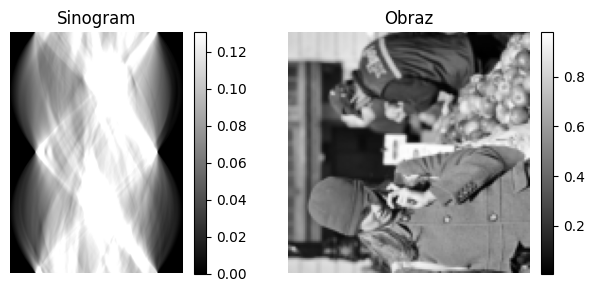

In [22]:
from matplotlib import pyplot as plt

def show_batch(loader):
    sinograms, images = next(iter(loader))
    print("Sinograms shape:", sinograms.shape)
    print("Images shape:", images.shape)

    bs = sinograms.shape[0]

    plt.figure(figsize=(7, 3 * bs))

    for i in range(bs):
        # Sinogram (lewa kolumna)
        ax1 = plt.subplot(bs, 2, 2 * i + 1)
        im1 = ax1.imshow(sinograms[i], cmap="gray")
        ax1.set_title("Sinogram")
        ax1.axis("off")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

        # Obraz (prawa kolumna)
        ax2 = plt.subplot(bs, 2, 2 * i + 2)
        im2 = ax2.imshow(images[i], cmap="gray")
        ax2.set_title("Obraz")
        ax2.axis("off")
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

show_batch(train_loader)

In [9]:
import numpy as np
import astra


def reconstruct_image_from_sinogram(sinogram, num_angles, img_size, algorithm="FBP_CUDA"):
    """
    Rekonstruuje obraz z sinogramu.

    Parametry:
        sinogram (ndarray): Sinogram (2D array)
        num_angles (int): Liczba kątów projekcji
        img_size (int): Rozmiar obrazu (np. 256)
        algorithm (str): Algorytm rekonstrukcji (domyślnie "FBP_CUDA")

    Zwraca:
        ndarray: zrekonstruowany obraz
    """
    # 1. Geometria projekcji (musi być taka sama jak przy tworzeniu sinogramu)
    angles = np.linspace(0, np.pi, num_angles, endpoint=False)
    proj_geom = astra.create_proj_geom("parallel", 1.0, sinogram.shape[1], angles)
    vol_geom = astra.create_vol_geom(img_size, img_size)

    # 2. Konfiguracja danych
    sinogram_id = astra.data2d.create("-sino", proj_geom, sinogram)

    # 3. Konfiguracja algorytmu FBP
    reco_id = astra.data2d.create("-vol", vol_geom)
    cfg = astra.astra_dict(algorithm)
    cfg["ReconstructionDataId"] = reco_id
    cfg["ProjectionDataId"] = sinogram_id

    if "CUDA" not in algorithm:
        cfg["ProjectorId"] = astra.create_projector("linear", proj_geom, vol_geom)

    alg_id = astra.algorithm.create(cfg)
    astra.algorithm.run(alg_id, iterations=1000)

    # 4. Pobierz wynik
    reconstruction = astra.data2d.get(reco_id)

    # 5. Czyszczenie zasobów
    astra.algorithm.delete(alg_id)
    astra.data2d.delete(reco_id)
    astra.data2d.delete(sinogram_id)

    return reconstruction

In [10]:
# Get one sinogram, image pair from the data loader
batch = next(iter(train_loader))
sinograms, images = batch

index = 0  # Choose item in the batch
sinogram = sinograms[index].numpy()
image = images[index].numpy()

print("Sinogram shape:", sinogram.shape)
print("Image shape:", image.shape)

Sinogram shape: (256, 183)
Image shape: (128, 128)


In [11]:
reconstruction = reconstruct_image_from_sinogram(
    sinogram, num_angles=256, img_size=128, algorithm="FBP"
)

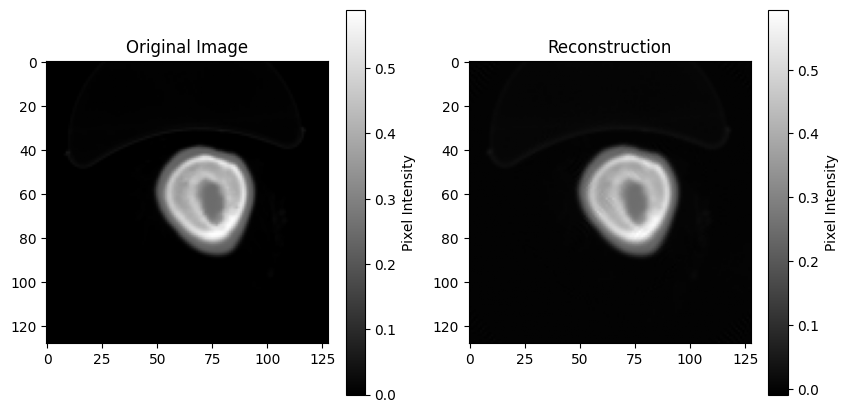

In [12]:
# Rotate image for correct orientation
image_rot = np.rot90(image)

# Rescale reconstruction to have the same min and max as the original image
# reconstruction = (reconstruction - reconstruction.min()) / (reconstruction.max() - reconstruction.min())
# reconstruction = reconstruction * (image_rot.max() - image_rot.min()) + image_rot.min()
reconstruction = reconstruction * 500

# Display the original image and reconstruction
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_rot, cmap="gray")
plt.colorbar(label='Pixel Intensity')

plt.subplot(1, 2, 2)
plt.title("Reconstruction")
plt.imshow(reconstruction, cmap="gray")
plt.colorbar(label='Pixel Intensity')

plt.gcf().set_size_inches(10, 5)
plt.show()

Maximum difference value: 0.0583132


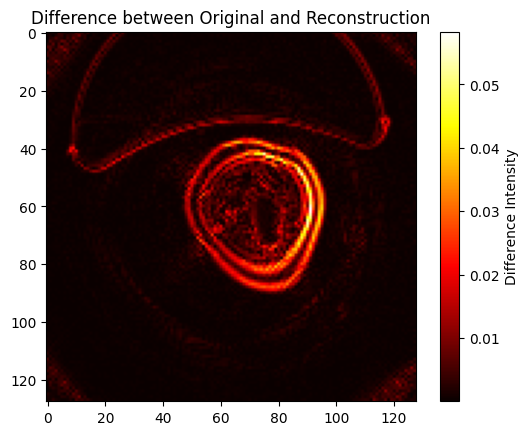

In [13]:
# Compare original and reconstruction pixel by pixel

difference = np.abs(image_rot.astype(np.float32) - reconstruction.astype(np.float32))

print("Maximum difference value:", np.max(difference))

plt.imshow(difference, cmap='hot')
plt.title("Difference between Original and Reconstruction")
plt.colorbar(label='Difference Intensity')
plt.show()

In [14]:
import math

def calculate_psnr(img1, img2, max_val=1.0):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_val) - 10 * math.log10(mse)

In [15]:
from skimage.metrics import structural_similarity as ssim

mse_diff = np.mean((image_rot - reconstruction) ** 2)
ssim_value = ssim(image_rot, reconstruction, data_range=image_rot.max() - image_rot.min())
psnr_value = calculate_psnr(image_rot, reconstruction, max_val=1.0)

print(f"MSE between original image and reconstruction: {mse_diff:.6f}")
print(f"SSIM between original image and reconstruction: {ssim_value:.4f}")
print(f"PSNR between original image and reconstruction: {psnr_value:.2f}")

MSE between original image and reconstruction: 0.000034
SSIM between original image and reconstruction: 0.9857
PSNR between original image and reconstruction: 44.72
